# 무신사 리뷰 텍스트 분석 — Step 3 ~ Step 5

본 노트북은 무신사 리뷰 데이터의 토픽 분석 파이프라인 중 **임베딩부터 HDBSCAN 클러스터링까지**를 다룹니다.

## 파이프라인 개요

```
[Step 1~2] 전처리 + 중복 처리           
[Step 3]   ko-sroberta 임베딩            
[Step 4]   UMAP 차원 축소                
[Step 5]   HDBSCAN 클러스터링            
[Step 6]   c-TF-IDF 토픽 키워드 추출  → step6_v4.ipynb 참조
```

## 입력

| 파일 | 설명 | 위치 |
|------|------|------|
| `embedding_input.parquet` | Step 2 완료된 정제 리뷰 (623,378건, 36개 컬럼) | `MyDrive/sparta/tp4/colab/data/` |

## 출력

| 파일 | 내용 | 비고 |
|------|------|------|
| `step3_1_embeddings.npy` | 문장 임베딩 (623378, 768) | float32, ~1.78GB |
| `step3_2_review_ids.npy` | 임베딩 i번째 ↔ 리뷰번호 매핑 | 후속 join 필수 |
| `step4_1_umap_embeddings.npy` | UMAP 5차원 결과 | 11.9MB |
| `step5_1_cluster_labels.npy` | HDBSCAN 클러스터 라벨 (73개 토픽) | -1 = outlier |
| `step5_2_hdbscan_model.pkl` | HDBSCAN 모델 객체 | 재현용 |

## 환경

- **Colab Pro + GPU 런타임 (A100)**
- 임베딩 모델: `jhgan/ko-sroberta-multitask`
- 형태소 분석기: `kiwipiepy`

## 실행 시간 (A100 기준)

| 단계 | 시간 |
|------|------|
| Step 3 임베딩 | ~25분 |
| Step 4 UMAP | ~20분 |
| Step 5 HDBSCAN | ~1분 |


---

# 0. 환경 셋업

처음 실행하거나 새 세션 시작 시 아래 셀들을 순서대로 실행합니다.

## 0-1. GPU 확인

Colab 메뉴: `런타임 → 런타임 유형 변경 → GPU` 설정 필요. **A100 권장.**

In [1]:
!nvidia-smi

Mon May 11 05:26:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 0-2. 라이브러리 일괄 설치

> **주의**: `hdbscan`은 numpy ABI 호환성 문제로 버전 핀을 잡지 않고 최신을 설치합니다. 따라서 설치 후 **런타임 재시작이 필요할 수 있습니다.**

In [2]:
!pip install -q sentence-transformers==2.7.0
!pip install -q umap-learn==0.5.6
!pip uninstall -y hdbscan
!pip install -q hdbscan
!pip install -q kiwipiepy
!pip install -q bertopic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.2 MB/s eta 0:00:00
Found existing installation: hdbscan 0.8.42
Uninstalling hdbscan-0.8.42:
  Successfully uninstalled hdbscan-0.8.42
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 127.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 29.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.6 MB/s eta 0:00:00


## 0-3. import, Google Drive 마운트

In [3]:
from google.colab import drive

import os
import time
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/sparta/tp4/review_analysis/data/'
INPUT_PATH = OUTPUT_DIR + 'embedding_input.parquet'

print(f'INPUT     : {INPUT_PATH}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

Mounted at /content/drive
INPUT     : /content/drive/MyDrive/sparta/tp4/review_analysis/data/embedding_input.parquet
OUTPUT_DIR: /content/drive/MyDrive/sparta/tp4/review_analysis/data/


---

# 환경 복원 (세션 끊김 시 사용)

> **사용 시기** : Colab 세션이 끊겨서 메모리 변수가 다 날아갔을 때.


In [5]:
# ─────────────────────────────────────────
# 환경 복원: 데이터 + 모든 중간 결과 + 토크나이저
# ─────────────────────────────────────────

# 1) docs (parquet에서 복원)
df_emb = pd.read_parquet(INPUT_PATH)
df_emb['리뷰내용_clean'] = df_emb['리뷰내용_clean'].fillna('').astype(str)
df_emb = df_emb[df_emb['리뷰내용_clean'].str.len() > 0].reset_index(drop=True)
docs = df_emb['리뷰내용_clean'].tolist()

# 2) 저장된 npy 파일들 (있는 것만 로드)
def safe_load(name):
    path = OUTPUT_DIR + name
    if os.path.exists(path):
        return np.load(path)
    print(f'없음: {name} (해당 단계 미완료)')
    return None

embeddings      = safe_load('step3_1_embeddings.npy')
review_ids      = safe_load('step3_2_review_ids.npy')
umap_embeddings = safe_load('step4_1_umap_embeddings.npy')
cluster_labels  = safe_load('step5_1_cluster_labels.npy')

# 3) 일관성 체크
if review_ids is not None:
    assert (df_emb['리뷰번호'].values == review_ids).all(), \
        'review_ids 순서 불일치'

print(f'✓ 복원 완료')
print(f'  docs:            {len(docs):,}건')
if embeddings      is not None: print(f'  embeddings:      {embeddings.shape}')
if umap_embeddings is not None: print(f'  umap_embeddings: {umap_embeddings.shape}')
if cluster_labels  is not None:
    print(f'  cluster_labels:  {cluster_labels.shape}')
    print(f'    토픽 수: {len(set(cluster_labels)) - 1}개, '
          f'outlier: {(cluster_labels == -1).sum():,}건')

✓ 복원 완료
  docs:            598,301건
  embeddings:      (598301, 768)
  umap_embeddings: (598301, 5)
  cluster_labels:  (598301,)
    토픽 수: 68개, outlier: 188,315건


**Step 6 작업 시 추가로 필요한 토크나이저** — `2_1_step6.ipynb`의 6-1, 6-2 셀 참고


---

# Step 3. 임베딩 (ko-sroberta-multitask)

## 목적
한국어 문장을 768차원 벡터로 변환하여, 의미가 유사한 리뷰가 벡터 공간에서 가깝게 배치되도록 함.

## 모델
`jhgan/ko-sroberta-multitask` — 한국어 문장 유사도 학습된 SBERT 모델

## 주의
- 정제된 문장을 **그대로** 입력 (형태소 분석 ✗) — SBERT는 자체 subword tokenizer 사용
- 임베딩 끝나면 **즉시 저장** (세션 끊김 대비)

## 3-1. 데이터 로드

In [6]:
df_emb = pd.read_parquet(INPUT_PATH)
df_emb['리뷰내용_clean'] = df_emb['리뷰내용_clean'].fillna('').astype(str)
df_emb = df_emb[df_emb['리뷰내용_clean'].str.len() > 0].reset_index(drop=True)

print(f'임베딩 대상: {len(df_emb):,}건')
print(f'컬럼 수: {df_emb.shape[1]}개')

docs = df_emb['리뷰내용_clean'].tolist()
review_ids = df_emb['리뷰번호'].tolist()

임베딩 대상: 598,301건
컬럼 수: 36개


## 3-2. 임베딩 모델 로드 + 인코딩

A100 기준 batch_size=64로 약 25분 소요.

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

embedding_model = SentenceTransformer('jhgan/ko-sroberta-multitask', device=device)

embeddings = embedding_model.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False  # cosine은 UMAP에서 metric='cosine'으로 처리
)

print(f'임베딩 shape: {embeddings.shape}')   # (N, 768)
print(f'dtype: {embeddings.dtype}')          # float32
print(f'예상 용량: {embeddings.nbytes / 1024**3:.2f} GB')

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/9349 [00:00<?, ?it/s]

임베딩 shape: (598301, 768)
dtype: float32
예상 용량: 1.71 GB


## 3-3. 저장

In [8]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(OUTPUT_DIR + 'step3_1_embeddings.npy', embeddings)
np.save(OUTPUT_DIR + 'step3_2_review_ids.npy', np.array(review_ids))

print('저장 완료:')
print(f'  embeddings.npy   shape={embeddings.shape}, '
      f'size={embeddings.nbytes / 1024**3:.2f} GB')
print(f'  review_ids.npy   len={len(review_ids):,}')

저장 완료:
  embeddings.npy   shape=(598301, 768), size=1.71 GB
  review_ids.npy   len=598,301


## 3-4. 임베딩 품질 검증

의미가 유사한 문장 쌍의 cosine 유사도가 0.8 이상이면 정상.

In [9]:
test_pairs = [
    ('배송이 너무 빨라요',     '배송 진짜 빠르네요'),       # 유사 (높아야 함)
    ('사이즈가 너무 작아요',   '핏이 커서 박시해요'),       # 반대 (낮아야 함)
    ('재질이 부드럽고 좋아요', '원단 퀄리티 만족합니다'),    # 유사 (높아야 함)
    ('배송이 너무 빨라요',     '사이즈가 너무 작아요'),     # 무관 (낮아야 함)
]

print('[의미 유사도 검증]')
for a, b in test_pairs:
    va = embedding_model.encode([a])
    vb = embedding_model.encode([b])
    sim = cosine_similarity(va, vb)[0][0]
    print(f'  {sim:.4f}   "{a}"  vs  "{b}"')

[의미 유사도 검증]
  0.8826   "배송이 너무 빨라요"  vs  "배송 진짜 빠르네요"
  0.3951   "사이즈가 너무 작아요"  vs  "핏이 커서 박시해요"
  0.6625   "재질이 부드럽고 좋아요"  vs  "원단 퀄리티 만족합니다"
  0.2102   "배송이 너무 빨라요"  vs  "사이즈가 너무 작아요"


---

# Step 4. UMAP 차원 축소

## 목적
768차원 임베딩을 5차원으로 압축. HDBSCAN의 클러스터링 성능을 위한 사전 단계.

## 파라미터 의미
- `n_neighbors=15`: 한 점이 참고할 이웃 수 (BERTopic 표준)
- `n_components=5`: 5차원으로 축소 (시각화 X, 클러스터링용)
- `min_dist=0.0`: 점들을 촘촘히 모음 (클러스터링용 표준)
- `metric='cosine'`: 임베딩 공간은 cosine이 표준

## 시간
A100 + CPU UMAP 기준 ~20분

## 4-1. UMAP 실행

In [10]:
print(f'입력 shape: {embeddings.shape}')

umap_model = UMAP(
    n_neighbors=15,        # 이웃 15명 참고. 작을수록 국소 구조, 클수록 전역 구조
    n_components=5,        # 5차원으로 축소 (시각화 X, 클러스터링 입력용)
    min_dist=0.0,          # 점들을 촘촘히 모음 (클러스터링용 표준)
    metric='cosine',       # 임베딩 공간은 코사인이 표준
    random_state=42,       # 재현성
    verbose=True           # 진행 로그
)

t0 = time.time()
umap_embeddings = umap_model.fit_transform(embeddings)
elapsed = time.time() - t0

print(f'\nUMAP 완료: {elapsed/60:.1f}분 소요')
print(f'출력 shape: {umap_embeddings.shape}')   # (623378, 5)

입력 shape: (598301, 768)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=5, n_jobs=1, random_state=42, verbose=True)
Mon May 11 05:34:18 2026 Construct fuzzy simplicial set
Mon May 11 05:34:20 2026 Finding Nearest Neighbors
Mon May 11 05:34:20 2026 Building RP forest with 44 trees
Mon May 11 05:36:49 2026 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	 4  /  19
	 5  /  19
	Stopping threshold met -- exiting after 5 iterations
Mon May 11 05:40:12 2026 Finished Nearest Neighbor Search
Mon May 11 05:40:19 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon May 11 05:53:57 2026 Finished embedding

UMAP 완료: 19.7분 소요
출력 shape: (598301, 5)


## 4-2. 저장

In [11]:
np.save(OUTPUT_DIR + 'step4_1_umap_embeddings.npy', umap_embeddings)

print(f'저장 완료: umap_embeddings.npy')
print(f'  shape: {umap_embeddings.shape}')
print(f'  size:  {umap_embeddings.nbytes / 1024**2:.1f} MB')
# UMAP 모델 저장 (새 데이터 transform용)
import pickle
with open(OUTPUT_DIR + 'step4_2_umap_model.pkl', 'wb') as f:
    pickle.dump(umap_model, f)
print('저장 완료: step4_2_umap_model.pkl')


저장 완료: umap_embeddings.npy
  shape: (598301, 5)
  size:  11.4 MB
Mon May 11 05:57:42 2026 Building hub-based search tree
Mon May 11 05:58:06 2026 Forward diversification reduced edges from 8974515 to 3511466
Mon May 11 05:58:13 2026 Reverse diversification reduced edges from 3511466 to 3511466
Mon May 11 05:58:16 2026 Degree pruning reduced edges from 4409182 to 4381635
Mon May 11 05:58:16 2026 Resorting data and graph based on tree order
Mon May 11 05:58:17 2026 Building and compiling search function
저장 완료: step4_2_umap_model.pkl


## 4-3. (선택) 시각화 — 분포 점검

본 분석에는 안 쓰고, 데이터가 잘 뭉치는지 시각적으로 점검만 합니다. 50,000건 샘플링.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


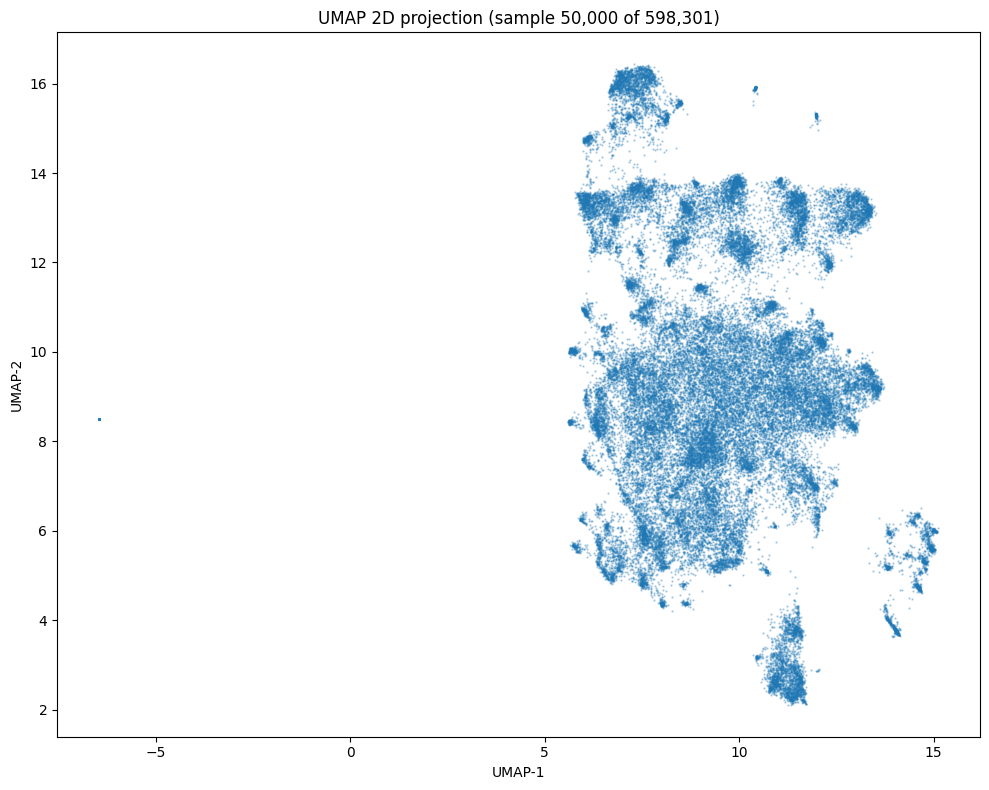

In [12]:
# 메모리 절약 위해 샘플 5만건만
sample_idx = np.random.choice(len(umap_embeddings), size=50000, replace=False)

umap_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
               metric='cosine', random_state=42).fit_transform(
    embeddings[sample_idx]   # 원본 768차원에서 다시 2D로 (5D→2D 아님)
)

plt.figure(figsize=(10, 8))
plt.scatter(umap_2d[:, 0], umap_2d[:, 1], s=0.5, alpha=0.3)
plt.title(f'UMAP 2D projection (sample {len(sample_idx):,} of {len(umap_embeddings):,})')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'step4_3_umap_2d_preview.png'), dpi=120)
plt.show()

---

# Step 5. HDBSCAN 클러스터링

## 목적
밀도 기반으로 비슷한 리뷰끼리 토픽으로 묶음. 애매한 리뷰는 -1 (outlier)로 분리.

## 파라미터 결정 과정
62만 건 데이터에서 `min_cluster_size`(mcs)를 조정하며 비교 실험을 수행:

| mcs | 토픽 수 | Outlier % | 최대 토픽 % |
|-----|---------|-----------|-------------|
| 100 | 371 | 36.8% | 4.7% |
| 200 | 251 | 34.9% | 4.7% |
| 500 | 151 | 34.8% | 4.7% |
| 1000 | 106 | 34.7% | 4.7% |
| **1500** | **73** | **34.1%** | **4.7%** ← 채택 |
| 2000 | 55 | 30.6% | **13.3%!!** |

→ mcs=2000부터 거대 단일 토픽이 형성되는 변곡점. **mcs=1500이 안정성 한계점**.

## 5-1. (참고) 파라미터 비교 실험

> 실제 본 실행 시에는 이 셀을 건너뛰어도 됩니다. 다른 데이터/조건에서 재실험하고 싶을 때만 사용.

In [13]:
# ─────────────────────────────────────────
# (참고) HDBSCAN 파라미터 비교 — 본 실행 전 탐색용
# ─────────────────────────────────────────

experiments = [
    {'min_cluster_size': 200,  'min_samples': 10},
    {'min_cluster_size': 500,  'min_samples': 10},
    {'min_cluster_size': 1000, 'min_samples': 10},
    {'min_cluster_size': 1500, 'min_samples': 10},
    {'min_cluster_size': 2000, 'min_samples': 10},
]

results = []
for exp in experiments:
    t0 = time.time()
    model = HDBSCAN(
        min_cluster_size=exp['min_cluster_size'],
        min_samples=exp['min_samples'],
        metric='euclidean',
        cluster_selection_method='eom',
        core_dist_n_jobs=-1
    )
    labels = model.fit_predict(umap_embeddings)
    elapsed = time.time() - t0

    n_total = len(labels)
    n_outliers = (labels == -1).sum()
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    sizes = pd.Series(labels[labels != -1]).value_counts() if n_clusters > 0 else pd.Series([])

    results.append({
        'min_cluster_size': exp['min_cluster_size'],
        'n_topics': n_clusters,
        'outlier_pct': round(n_outliers / n_total * 100, 1),
        'biggest_topic': int(sizes.max()) if len(sizes) > 0 else 0,
        'biggest_pct': round(sizes.max() / n_total * 100, 1) if len(sizes) > 0 else 0,
        'median_size': int(sizes.median()) if len(sizes) > 0 else 0,
        'time_min': round(elapsed / 60, 1),
    })
    print(f"  완료: mcs={exp['min_cluster_size']} → "
          f"{n_clusters}개 토픽, outlier {n_outliers/n_total*100:.1f}%")

print('\n[비교 결과]')
print(pd.DataFrame(results).to_string(index=False))

  완료: mcs=200 → 244개 토픽, outlier 32.8%
  완료: mcs=500 → 147개 토픽, outlier 34.0%
  완료: mcs=1000 → 94개 토픽, outlier 32.8%
  완료: mcs=1500 → 68개 토픽, outlier 31.5%
  완료: mcs=2000 → 49개 토픽, outlier 26.6%

[비교 결과]
 min_cluster_size  n_topics  outlier_pct  biggest_topic  biggest_pct  median_size  time_min
              200       244         32.8          28411          4.7          685       0.6
              500       147         34.0          28411          4.7         1438       0.6
             1000        94         32.8          28411          4.7         2660       0.6
             1500        68         31.5          30248          5.1         3396       0.6
             2000        49         26.6          64719         10.8         4289       0.6


## 5-2. HDBSCAN 본 실행

확정 파라미터: `min_cluster_size=1500, min_samples=10`(추후 튜닝 예정)

> `prediction_data=False`: 새 문서 예측 기능을 **비활성화**. 메모리 절약 + 분석 단계에서는 불필요.

In [14]:
print(f'입력 shape: {umap_embeddings.shape}')

hdbscan_model = HDBSCAN(
    min_cluster_size=1500,           # 1500건 이상 모인 영역만 토픽으로 인정
    min_samples=10,                  # outlier 판정 민감도
    metric='euclidean',              # UMAP 출력 공간은 유클리디안이 표준
    cluster_selection_method='eom',  # Excess of Mass: BERTopic 권장
    prediction_data=True,           # 새 문서 예측 기능 비활성화 (메모리 절약)
    core_dist_n_jobs=-1              # 병렬 처리
)

t0 = time.time()
cluster_labels = hdbscan_model.fit_predict(umap_embeddings)
elapsed = time.time() - t0

print(f'\nHDBSCAN 완료: {elapsed/60:.1f}분 소요')

# ── 중간 저장 (세션 끊김 대비) ───────────────────────────────────────
np.save(OUTPUT_DIR + 'step5_1_cluster_labels.npy', cluster_labels)
with open(OUTPUT_DIR + 'step5_2_hdbscan_model.pkl', 'wb') as f:
    pickle.dump(hdbscan_model, f)
print('저장 완료: cluster_labels.npy, hdbscan_model.pkl')

입력 shape: (598301, 5)

HDBSCAN 완료: 0.8분 소요
저장 완료: cluster_labels.npy, hdbscan_model.pkl


## 5-3. 결과 진단

In [15]:
n_total = len(cluster_labels)
n_outliers = (cluster_labels == -1).sum()
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print(f'[클러스터링 결과]')
print(f'  전체 문서:      {n_total:,}건')
print(f'  토픽 수:        {n_clusters}개')
print(f'  Outlier (-1):  {n_outliers:,}건 ({n_outliers/n_total*100:.1f}%)')
print(f'  클러스터링됨:   {n_total - n_outliers:,}건 ({(n_total-n_outliers)/n_total*100:.1f}%)')

# 클러스터별 크기 분포
cluster_sizes = pd.Series(cluster_labels[cluster_labels != -1]).value_counts()
print(f'\n[토픽 크기 분포]')
print(cluster_sizes.describe())

print(f'\n[상위 15개 토픽]')
print(cluster_sizes.head(15))

[클러스터링 결과]
  전체 문서:      598,301건
  토픽 수:        68개
  Outlier (-1):  188,315건 (31.5%)
  클러스터링됨:   409,986건 (68.5%)

[토픽 크기 분포]
count       68.000000
mean      6029.205882
std       6067.092592
min       1519.000000
25%       2452.750000
50%       3396.500000
75%       7155.500000
max      30248.000000
Name: count, dtype: float64

[상위 15개 토픽]
6     30248
2     28411
15    19246
64    18853
13    18682
46    15609
63    14480
19    14385
51    13723
12    12355
61     9607
39     9303
67     9137
60     8279
33     7763
Name: count, dtype: int64


## 5-4. 저장

In [16]:
np.save(OUTPUT_DIR + 'step5_1_cluster_labels.npy', cluster_labels)

with open(OUTPUT_DIR + 'step5_2_hdbscan_model.pkl', 'wb') as f:
    pickle.dump(hdbscan_model, f)

print(f'저장 완료:')
print(f'  cluster_labels.npy   shape={cluster_labels.shape}')
print(f'  hdbscan_model.pkl')

저장 완료:
  cluster_labels.npy   shape=(598301,)
  hdbscan_model.pkl


## 5-5. (선택) 시각화 — 클러스터 분포 점검

시각화용 2D UMAP 계산 중...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


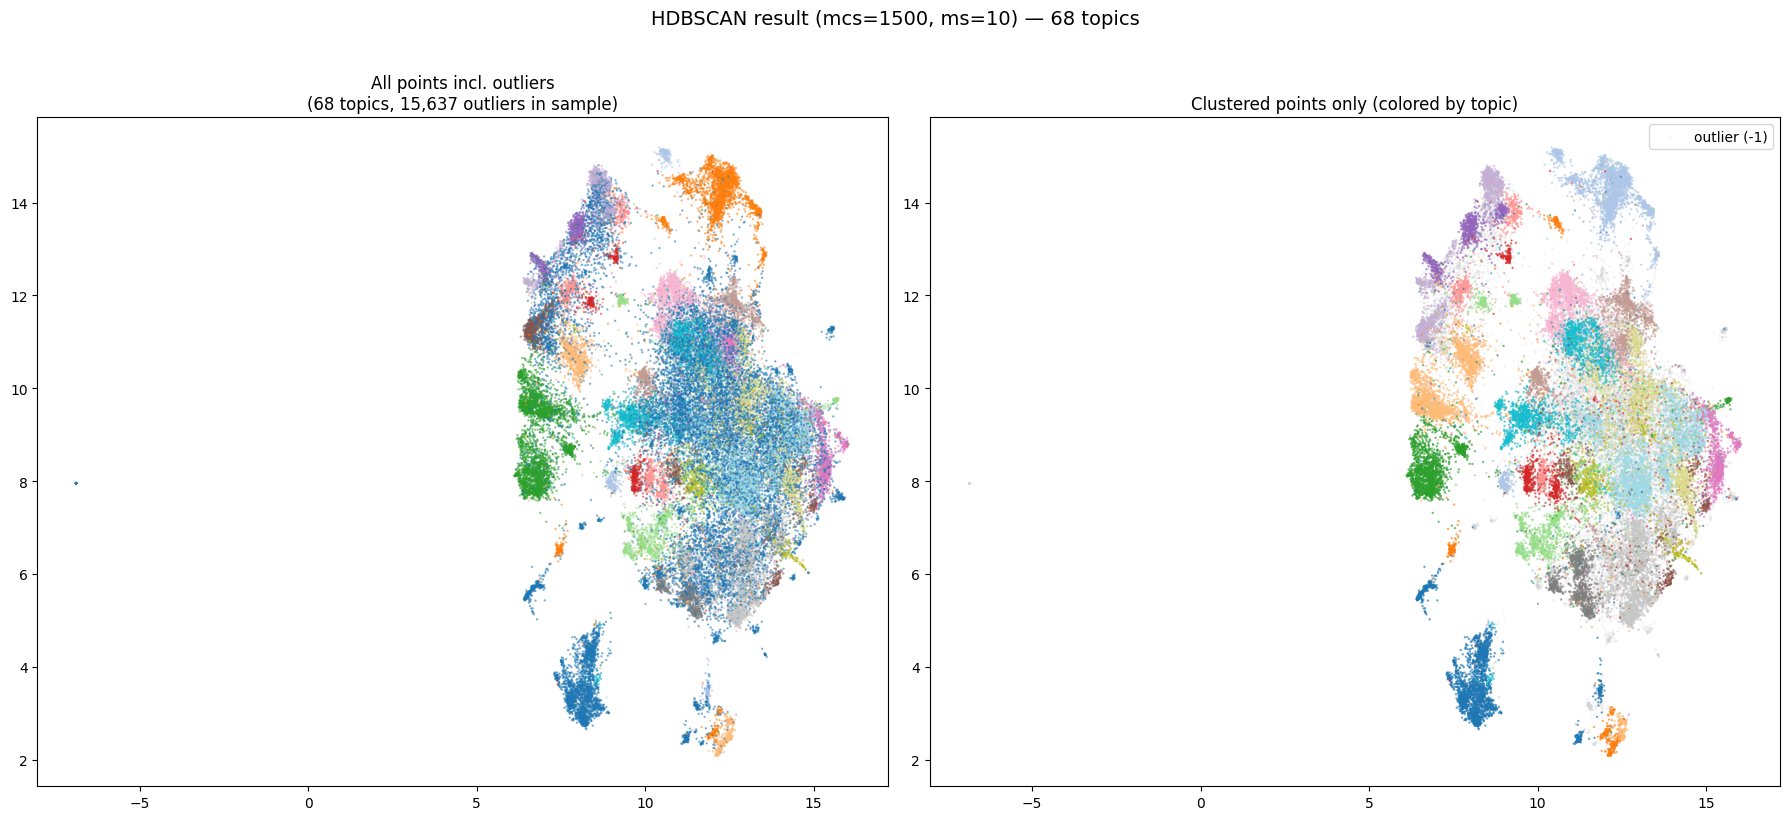

In [17]:
sample_idx = np.random.choice(len(umap_embeddings), size=50000, replace=False)

print('시각화용 2D UMAP 계산 중...')
sample_2d = UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1,
    metric='cosine', random_state=42,
).fit_transform(embeddings[sample_idx])

sample_labels = cluster_labels[sample_idx]
n_outliers_sample = (sample_labels == -1).sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (좌) 모든 점
axes[0].scatter(sample_2d[:, 0], sample_2d[:, 1],
                c=sample_labels, s=0.5, alpha=0.5, cmap='tab20')
axes[0].set_title(f'All points incl. outliers\n'
                  f'({n_clusters} topics, {n_outliers_sample:,} outliers in sample)')

# (우) outlier는 회색
mask_clustered = sample_labels != -1
axes[1].scatter(sample_2d[~mask_clustered, 0], sample_2d[~mask_clustered, 1],
                c='lightgray', s=0.3, alpha=0.3, label='outlier (-1)')
axes[1].scatter(sample_2d[mask_clustered, 0], sample_2d[mask_clustered, 1],
                c=sample_labels[mask_clustered], s=0.5, alpha=0.6, cmap='tab20')
axes[1].set_title('Clustered points only (colored by topic)')
axes[1].legend(loc='upper right')

plt.suptitle(f'HDBSCAN result (mcs=1500, ms=10) — {n_clusters} topics',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'step5_3_hdbscan_2d_preview.png', dpi=120, bbox_inches='tight')
plt.show()